In [1]:
#import
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, f1_score
from sklearn.preprocessing import LabelEncoder
import joblib
from google.colab import files
import io
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

In [2]:
# reading and prepare dataset
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[file_name]))
le = LabelEncoder()
df['province'] = le.fit_transform(df['province'])

Saving flood_dataset.csv to flood_dataset.csv


In [3]:
# set features (X) and target (y)
X = df.drop(columns=['flooding'])
y = df['flooding']

# set train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)


In [4]:
# create model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [5]:
# predict
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", round(acc, 4))
print("Precision:", round(prec, 4))
print("F1 Score:", round(f1, 4))

Accuracy: 0.9639
Precision: 0.9706
F1 Score: 0.6226


In [8]:
# export model
joblib.dump(model, "flood_model.pkl")
joblib.dump(le, "label_encoder.pkl")

['label_encoder.pkl']

Shape of data: (5544, 7)

Missing values per column: province                          0
month                             0
MinRain                           0
MaxRain                           0
AvgRain                           0
AvgFloodRiskArea(Square meter)    0
flooding                          0
dtype: int64

Null/NaN values exist? -> False

Duplicate rows: 70

Descriptive Statistics:
           province        month      MinRain      MaxRain      AvgRain  \
count  5544.000000  5544.000000  5544.000000  5544.000000  5544.000000   
mean     31.000000     6.318182    82.127659   191.277940   128.532475   
std      18.185882     3.482560    96.108862   189.090436   131.719032   
min       0.000000     1.000000     0.000000     0.000000     0.000000   
25%      15.000000     3.000000     3.800000    36.415000    17.469487   
50%      31.000000     6.000000    52.434999   153.029998   100.751952   
75%      47.000000     9.000000   130.509995   279.720009   196.232829   
90%      56

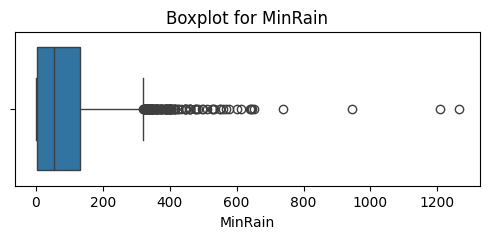


Outliers in MaxRain: 182 rows


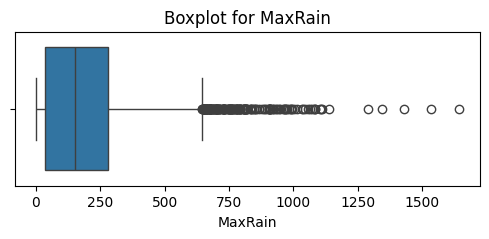


Outliers in AvgRain: 139 rows


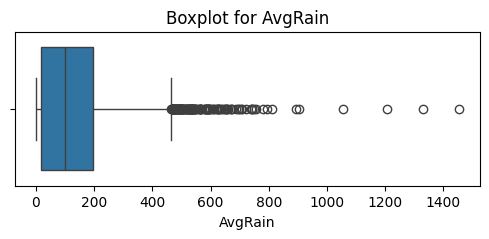


Outliers in AvgFloodRiskArea(Square meter): 176 rows


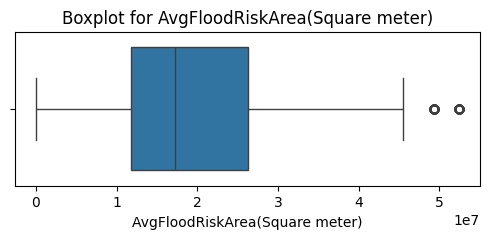

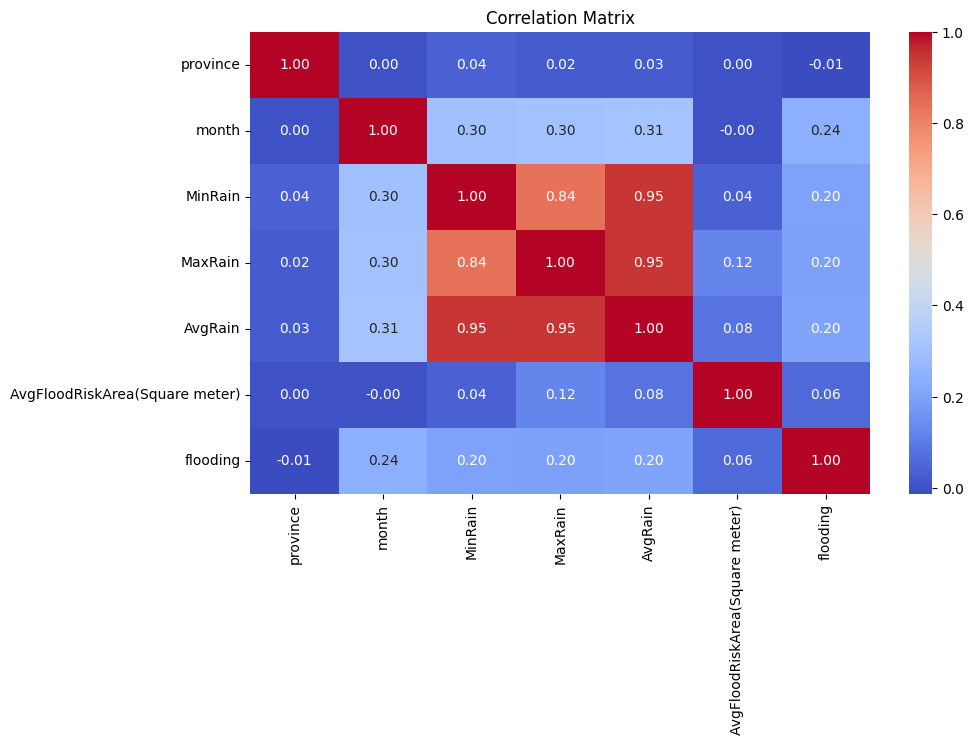

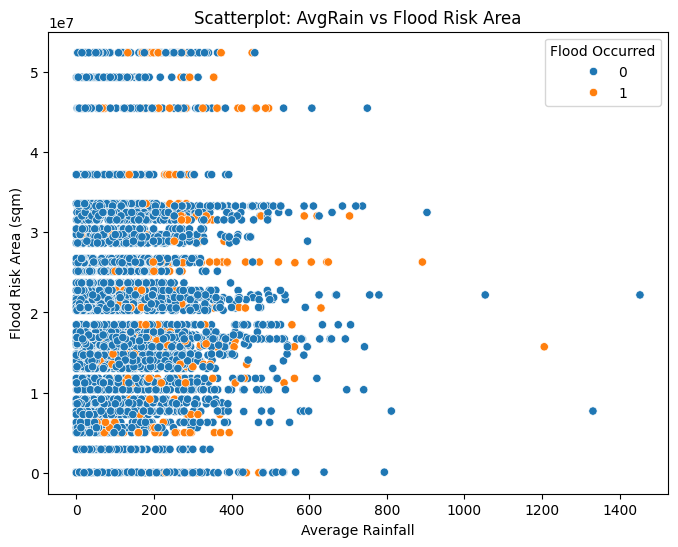

In [7]:
# Shape data
print("Shape of data:", df.shape)

# Missing values
print("\nMissing values per column:", df.isnull().sum())

# Null & NaN values
print("\nNull/NaN values exist? ->", df.isnull().values.any())

# Duplicate rows
duplicates = df.duplicated().sum()
print("\nDuplicate rows:", duplicates)

# Descriptive Statistics (รวม percentiles)
percentiles = [0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
desc = df.describe(percentiles=percentiles)
print("\nDescriptive Statistics:\n", desc)
print(df.columns.tolist())

# Outlier Detection (ใช้ boxplot และ IQR method)
numeric_cols = ['MinRain', 'MaxRain', 'AvgRain', 'AvgFloodRiskArea(Square meter)']
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"\nOutliers in {col}: {len(outliers)} rows")

    # Boxplot แสดง outliers
    plt.figure(figsize=(6, 2))
    sns.boxplot(data=df, x=col)
    plt.title(f"Boxplot for {col}")
    plt.show()

# ✅ 7. Correlation Matrix (เฉพาะ numeric)
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

# ✅ 8. Bivariate Analysis – Scatterplot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='AvgRain', y='AvgFloodRiskArea(Square meter)', hue='flooding')
plt.title("Scatterplot: AvgRain vs Flood Risk Area")
plt.xlabel("Average Rainfall")
plt.ylabel("Flood Risk Area (sqm)")
plt.legend(title="Flood Occurred")
plt.show()